In [1]:
!pip install pandas numpy matplotlib seaborn plotly missingno openpyxl

In [2]:
import os
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import missingno as msno

warnings.filterwarnings("ignore")

plt.style.use("ggplot")
pd.set_option("display.max_columns", None)

In [3]:
from google.colab import files

uploaded = files.upload()

Saving paper_data.csv to paper_data.csv


In [4]:
df = pd.read_csv("paper_data.csv")

df.head()

,timestamp,recipe_id,target_basis_weight,actual_basis_weight,stock_flow,filler_flow,steam_pressure,machine_speed,moisture,ash,caliper,deviation_percent,risk_level
0,2026-01-01 08:00:00,103,80,80.66,102.79,16.23,121.53,960.66,4.92,13.51,0.14,0.83,SAFE
1,2026-01-01 08:00:05,103,80,79.58,97.77,11.64,120.78,970.99,6.04,9.41,0.15,0.52,SAFE
2,2026-01-01 08:00:10,103,80,79.98,96.90,17.47,120.83,964.57,6.06,12.33,0.12,0.02,SAFE
3,2026-01-01 08:00:15,103,80,80.39,102.49,15.60,122.35,961.38,5.96,9.55,0.12,0.48,SAFE
4,2026-01-01 08:00:20,103,80,79.74,98.74,13.91,122.39,965.10,5.91,11.97,0.11,0.32,SAFE


In [5]:
print(df.shape)

print(df.columns.tolist())

(20000, 13)
['timestamp', 'recipe_id', 'target_basis_weight', 'actual_basis_weight', 'stock_flow', 'filler_flow', 'steam_pressure', 'machine_speed', 'moisture', 'ash', 'caliper', 'deviation_percent', 'risk_level']


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   timestamp            20000 non-null  object 
 1   recipe_id            20000 non-null  int64  
 2   target_basis_weight  20000 non-null  int64  
 3   actual_basis_weight  20000 non-null  float64
 4   stock_flow           20000 non-null  float64
 5   filler_flow          20000 non-null  float64
 6   steam_pressure       20000 non-null  float64
 7   machine_speed        20000 non-null  float64
 8   moisture             20000 non-null  float64
 9   ash                  20000 non-null  float64
 10  caliper              20000 non-null  float64
 11  deviation_percent    20000 non-null  float64
 12  risk_level           20000 non-null  object 
dtypes: float64(9), int64(2), object(2)
memory usage: 2.0+ MB


In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
recipe_id,20000.0,103.975000,1.350728,101.00,103.00,105.000,105.000,105.00
target_basis_weight,20000.0,89.750000,13.507280,60.00,80.00,100.000,100.000,100.00
actual_basis_weight,20000.0,89.755905,13.527666,55.87,80.43,98.680,100.050,105.08
stock_flow,20000.0,110.366735,12.506124,80.01,102.04,115.460,120.210,125.00
filler_flow,20000.0,13.997181,2.313798,10.00,11.98,14.020,15.990,18.00
steam_pressure,20000.0,122.593891,2.843175,115.00,120.79,122.950,124.760,127.00
machine_speed,20000.0,926.123909,68.889718,850.01,873.59,897.615,964.245,1099.99
moisture,20000.0,5.502931,0.406650,4.80,5.15,5.510,5.860,6.20
ash,20000.0,11.497661,2.020336,8.00,9.76,11.480,13.260,15.00
caliper,20000.0,0.114888,0.020611,0.08,0.10,0.110,0.130,0.15


In [8]:
df.isnull().sum()

,0
timestamp,0
recipe_id,0
target_basis_weight,0
actual_basis_weight,0
stock_flow,0
filler_flow,0
steam_pressure,0
machine_speed,0
moisture,0
ash,0


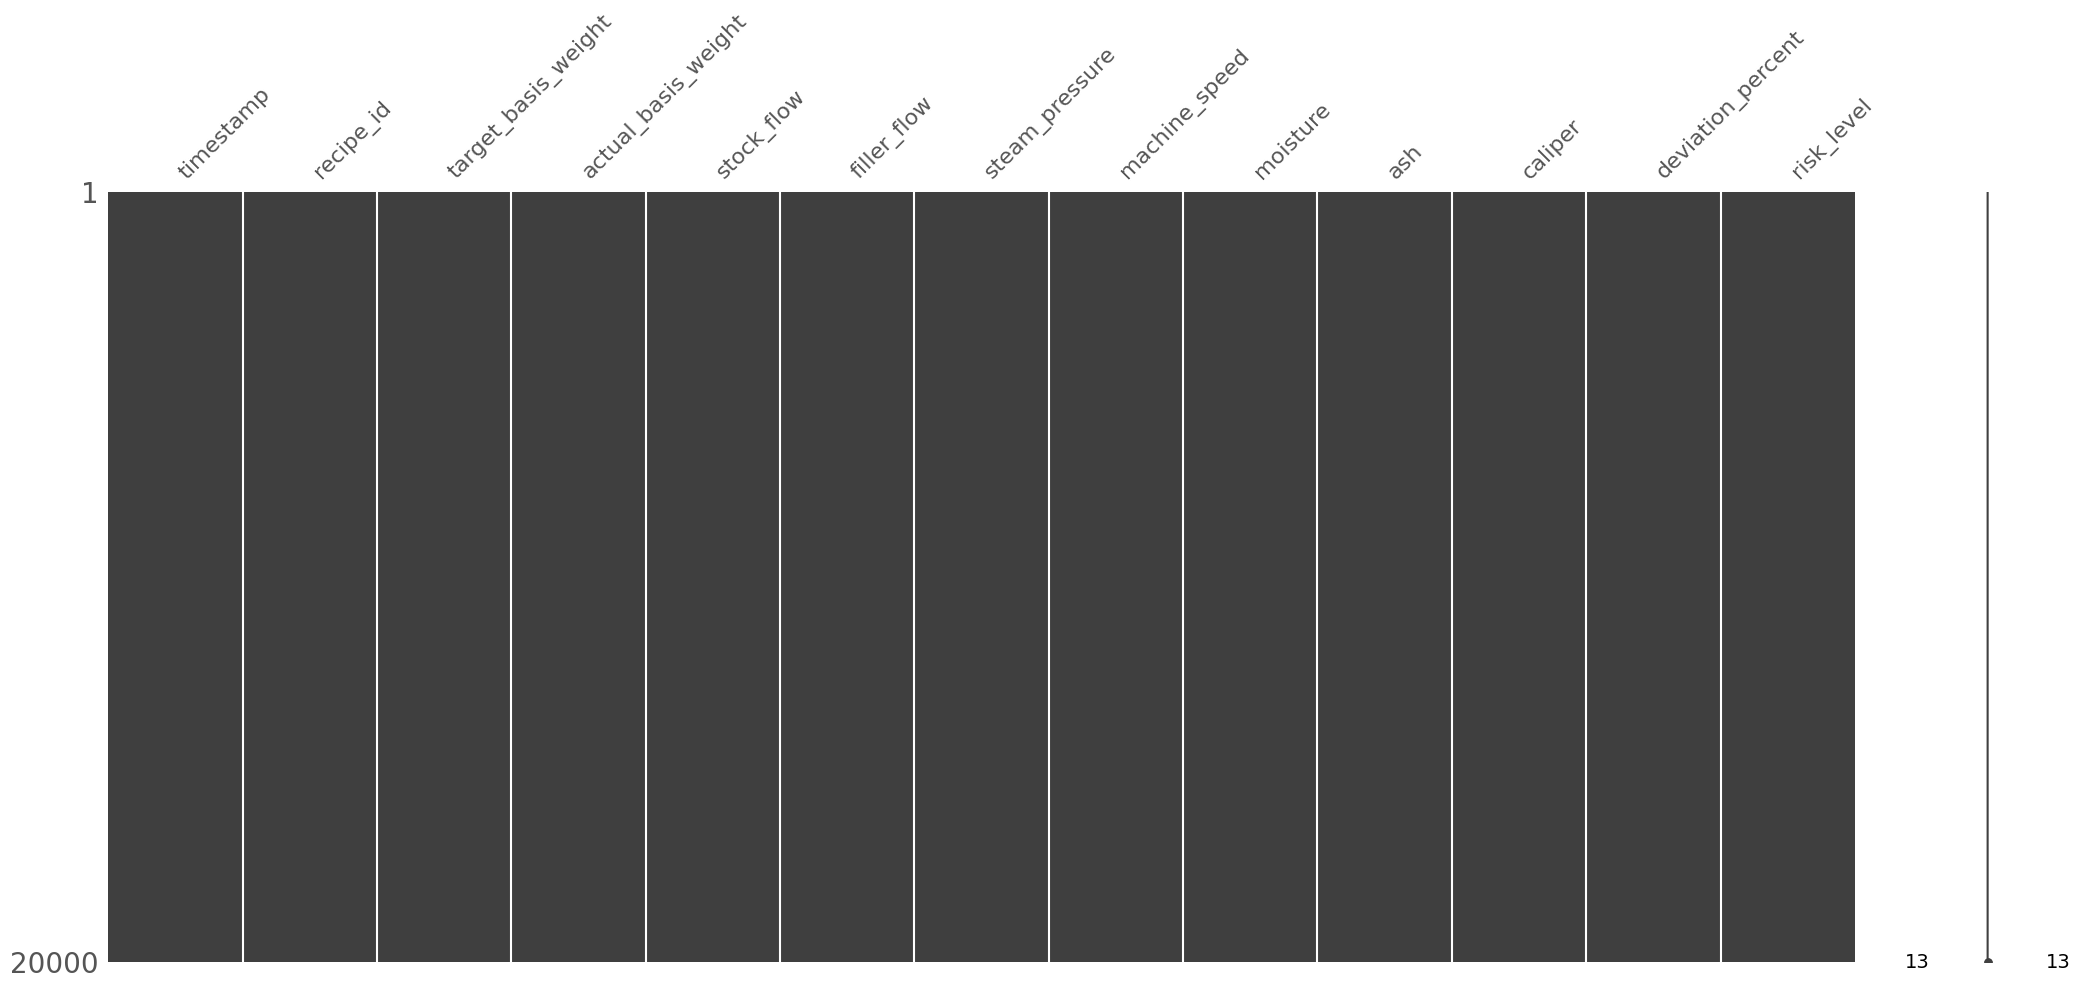

In [9]:
msno.matrix(df)
plt.show()

In [10]:
print(df.duplicated().sum())

0


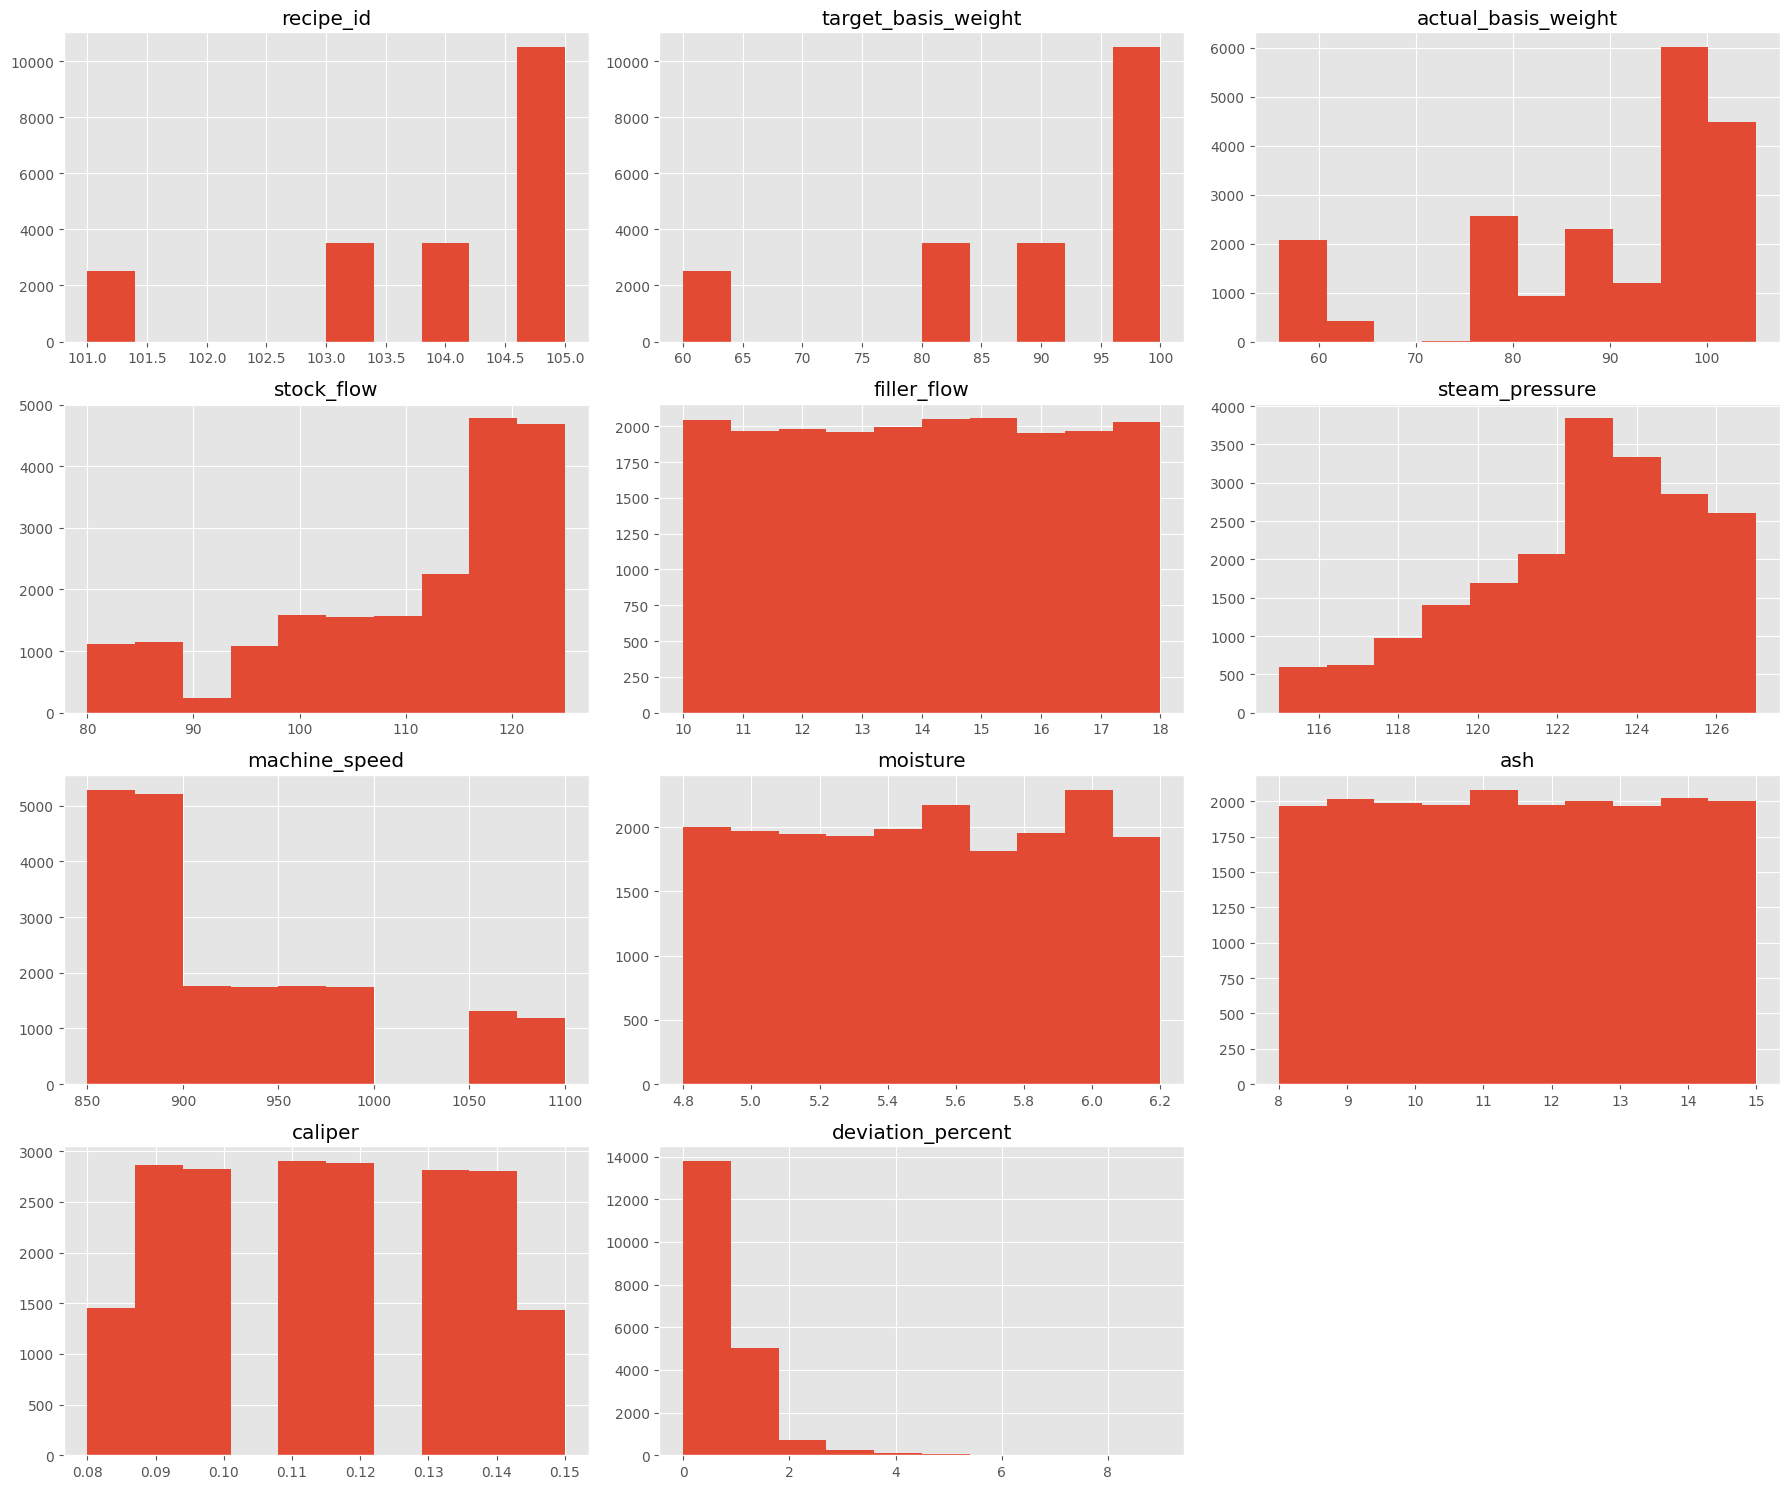

In [11]:
numeric = df.select_dtypes(include=np.number)

numeric.hist(figsize=(18,15))

plt.tight_layout()

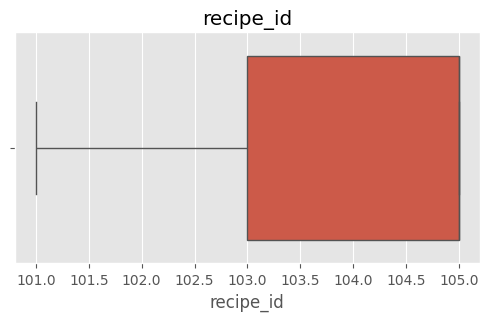

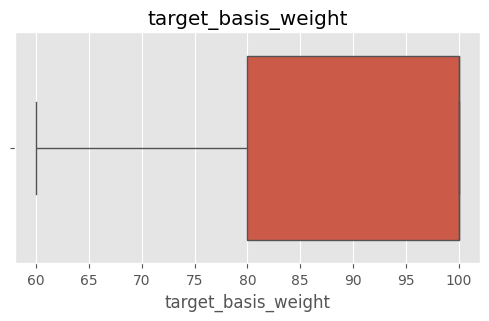

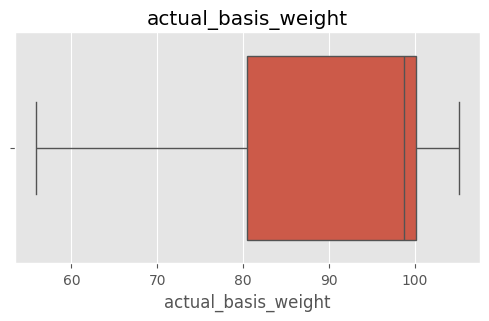

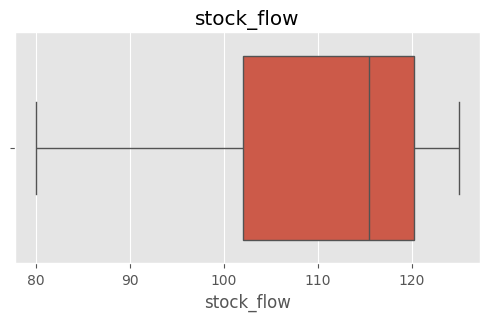

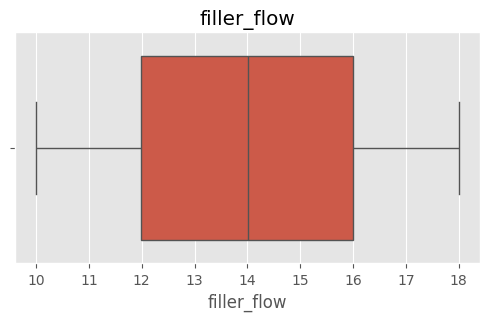

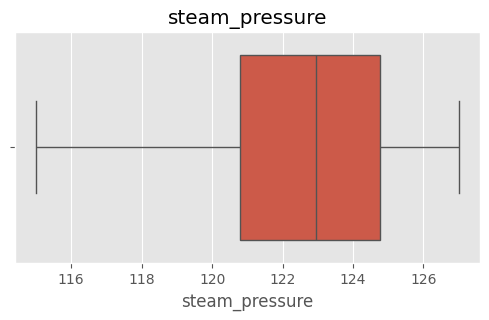

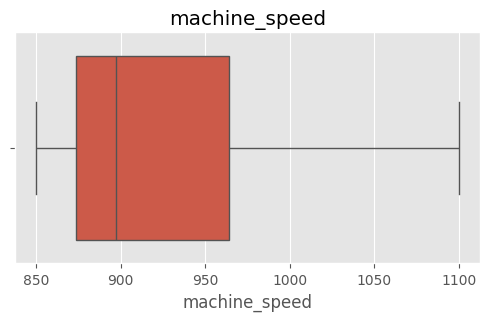

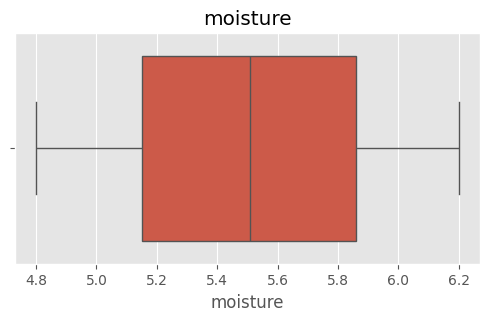

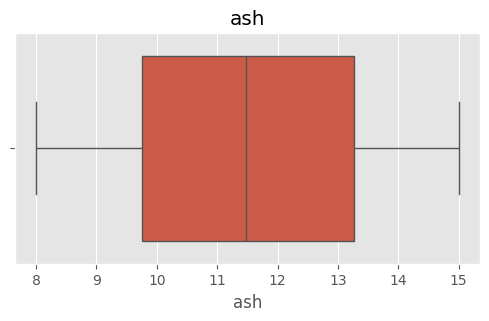

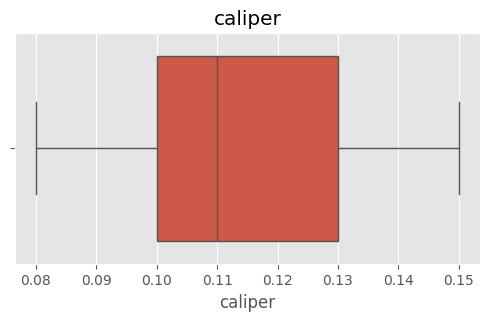

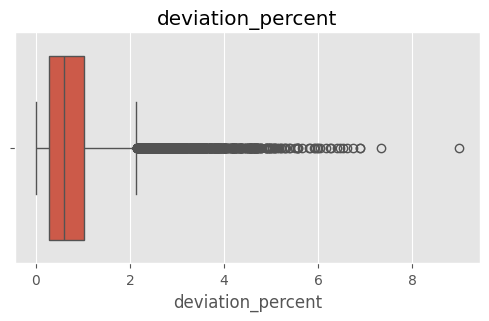

In [12]:
for col in numeric.columns:

    plt.figure(figsize=(6,3))

    sns.boxplot(x=df[col])

    plt.title(col)

    plt.show()

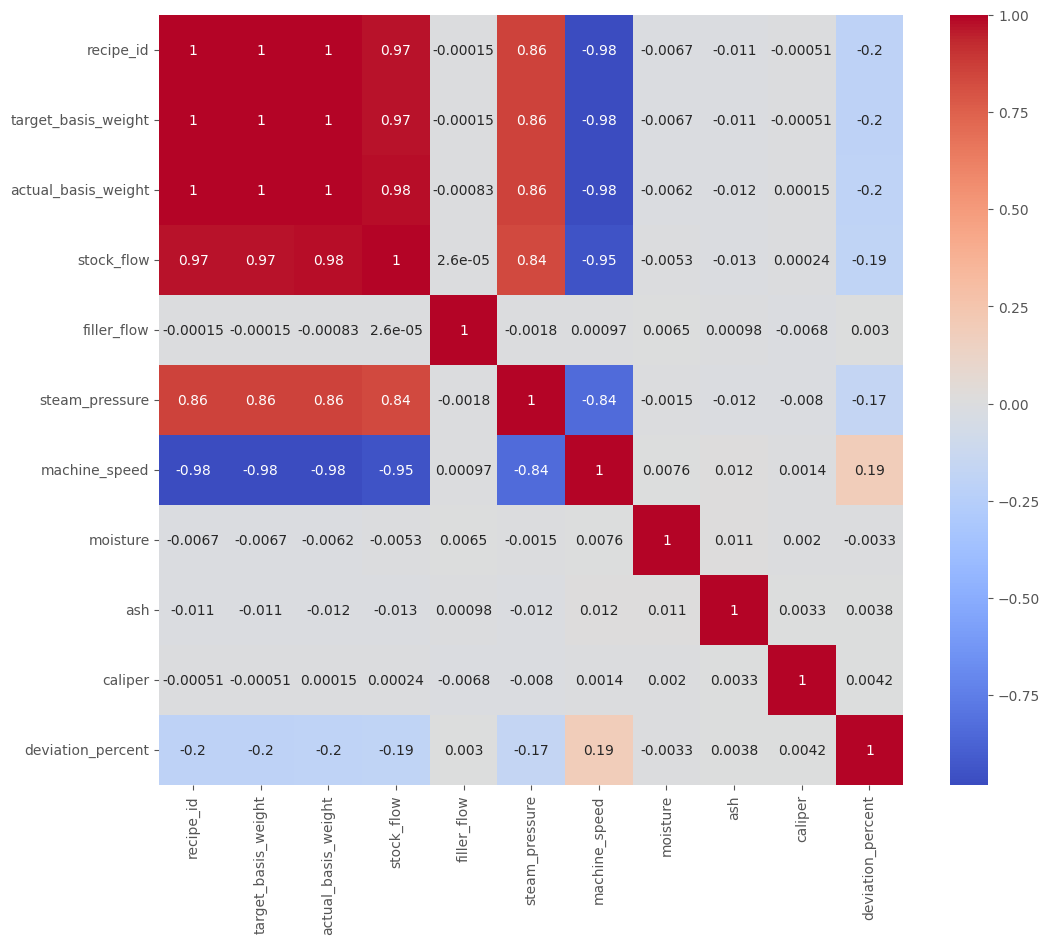

In [13]:
plt.figure(figsize=(12,10))

sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap="coolwarm")

plt.show()

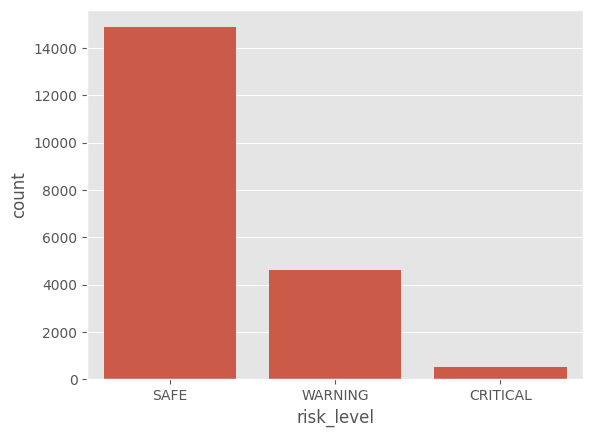

In [14]:
sns.countplot(data=df,
              x="risk_level")

plt.show()

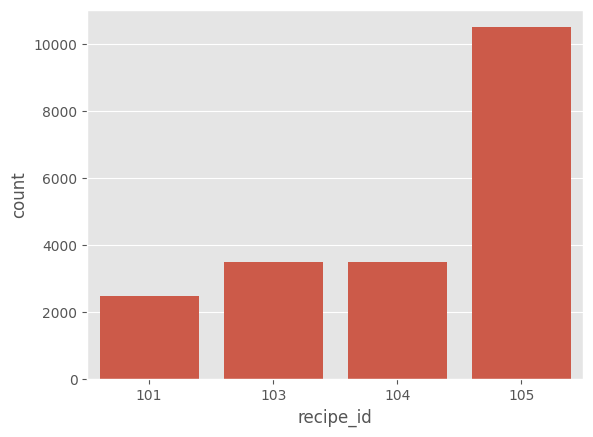

In [15]:
sns.countplot(data=df,
              x="recipe_id")

plt.show()

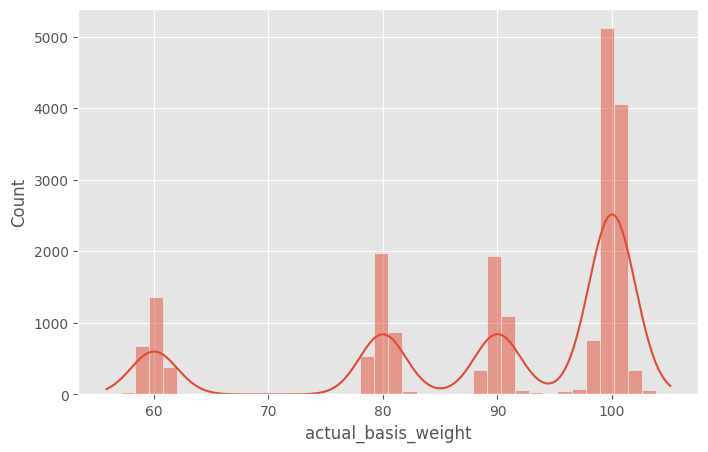

In [16]:
plt.figure(figsize=(8,5))

sns.histplot(df["actual_basis_weight"],
             bins=40,
             kde=True)

plt.show()

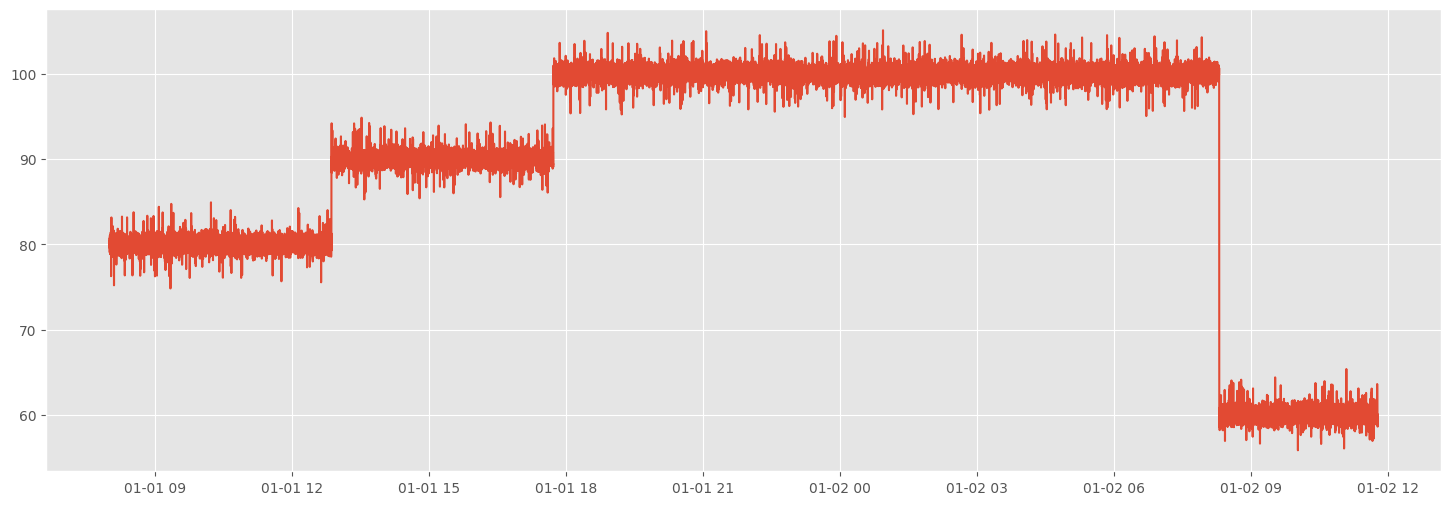

In [17]:
df["timestamp"] = pd.to_datetime(df["timestamp"])

plt.figure(figsize=(18,6))

plt.plot(df["timestamp"],
         df["actual_basis_weight"])

plt.show()

In [18]:
df.to_csv("clean_data.csv",
          index=False)

In [19]:
files.download("clean_data.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>